# 10K middle-scale mDST campaign status

Real-data-only operator notebook for manifest, Condor-log,
provenance, and full-shard validation. It never substitutes a
fixture. Override `HYPERTAGGING_10K_CAMPAIGN_ROOT` to inspect a
relocated campaign.

## tl;dr

In [1]:
from collections import Counter
import json, os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

CAMPAIGN_ROOT = Path(os.environ.get(
    "HYPERTAGGING_10K_CAMPAIGN_ROOT",
    "/data/dust/user/boyangyu/hypertagging/production_10k_middle_20260804",
))
MANIFEST = Path(os.environ.get(
    "HYPERTAGGING_10K_MANIFEST",
    CAMPAIGN_ROOT / "manifests" / "mdst_10k_random_seed_20260804_v3.jsonl",
))
SOURCE_ROOT = Path(os.environ.get(
    "HYPERTAGGING_10K_SOURCE_ROOT",
    CAMPAIGN_ROOT / "source" / "d02e823e0cbc",
))
REPORT_ROOT = Path(os.environ.get(
    "HYPERTAGGING_10K_REPORT_ROOT", CAMPAIGN_ROOT / "inspection"
))
REPORT_ROOT.mkdir(parents=True, exist_ok=True)
sys.path[:0] = [str(SOURCE_ROOT), str(SOURCE_ROOT / "src")]
from scripts import mdst_batch_production as production

if not MANIFEST.is_file():
    raise FileNotFoundError(f"Real campaign manifest is required: {MANIFEST}")
records = production.read_manifest(MANIFEST)
status = production.production_status(MANIFEST)
require_complete = os.environ.get("HYPERTAGGING_REQUIRE_COMPLETE", "1") == "1"
tldr = {
    "campaign_id": status["campaign_id"],
    "planned_events": sum(int(row["planned_events"]) for row in records),
    "tasks": len(records),
    "complete_valid": status["complete"],
    "missing_or_invalid": status["missing_or_invalid"],
    "source_commit": records[0]["source_git_commit"],
}
print(json.dumps(tldr, indent=2))
if require_complete and status["missing_or_invalid"]:
    raise RuntimeError(f"Campaign is not complete: {status['classifications']}")

{
  "campaign_id": "campaign-6929dab450f3-35d8a1e19134",
  "planned_events": 10000,
  "tasks": 20,
  "complete_valid": 20,
  "missing_or_invalid": 0,
  "source_commit": "35d8a1e19134fed6d468e531350aa3ee9d153351"
}


## Context & Methods

### Key Assumptions

The JSONL manifest is authoritative. Validity means the
Parquet file, metadata sidecar, and completion marker all
satisfy the manifest-bound schema-v4 provenance contract.
Condor logs are diagnostic evidence, not a substitute for
shard validation.

In [2]:
summary_path = MANIFEST.with_suffix(".summary.json")
sample_path = MANIFEST.parent / "mdst_10k_sampled_inputs_v3.json"
summary = json.loads(summary_path.read_text())
sample = json.loads(sample_path.read_text())
context = {
    "manifest": str(MANIFEST),
    "input_root": summary["input_root"],
    "output_root": summary["output_root"],
    "selection_strategy": sample["selection_strategy"],
    "random_seed": sample["random_seed"],
    "selected_input_files": len(sample["selected_input_files_in_manifest_order"]),
    "events_per_task": summary["events_per_task"],
    "source_state": summary["source_state"],
}
display(pd.DataFrame(context.items(), columns=["parameter", "value"]))

,parameter,value
0,manifest,/data/dust/user/boyangyu/hypertagging/producti...
1,input_root,/pnfs/desy.de/belle/local/belle/MC/release-08-...
2,output_root,/data/dust/user/boyangyu/hypertagging/producti...
3,selection_strategy,category_stratified_without_replacement
4,random_seed,20260804
5,selected_input_files,14
6,events_per_task,500
7,source_state,clean


## Data

In [3]:
frame = pd.DataFrame(records)
configured_input_root = Path(summary["input_root"])
configured_output_root = Path(summary["output_root"])
frame["input_exists"] = frame.input_file.map(lambda value: Path(value).is_file())
frame["input_under_configured_root"] = frame.input_file.map(
    lambda value: Path(value).is_relative_to(configured_input_root)
)
frame["output_under_configured_root"] = frame.output_file.map(
    lambda value: Path(value).is_relative_to(configured_output_root)
)
assert frame.planned_events.sum() == 10_000
assert frame.task_id.is_unique
assert frame.input_exists.all()
assert frame.input_under_configured_root.all()
assert frame.output_under_configured_root.all()
display(frame[[
    "task_id", "physics_category", "input_file", "entry_sequence",
    "planned_events", "output_file",
]])

,task_id,physics_category,input_file,entry_sequence,planned_events,output_file
0,0,ccbar,/pnfs/desy.de/belle/local/belle/MC/release-08-...,0:499,500,/data/dust/user/boyangyu/hypertagging/producti...
1,1,charged,/pnfs/desy.de/belle/local/belle/MC/release-08-...,0:499,500,/data/dust/user/boyangyu/hypertagging/producti...
2,2,ddbar,/pnfs/desy.de/belle/local/belle/MC/release-08-...,0:499,500,/data/dust/user/boyangyu/hypertagging/producti...
3,3,mixed,/pnfs/desy.de/belle/local/belle/MC/release-08-...,0:499,500,/data/dust/user/boyangyu/hypertagging/producti...
4,4,ssbar,/pnfs/desy.de/belle/local/belle/MC/release-08-...,0:499,500,/data/dust/user/boyangyu/hypertagging/producti...
5,5,taupair,/pnfs/desy.de/belle/local/belle/MC/release-08-...,0:499,500,/data/dust/user/boyangyu/hypertagging/producti...
6,6,uubar,/pnfs/desy.de/belle/local/belle/MC/release-08-...,0:499,500,/data/dust/user/boyangyu/hypertagging/producti...
7,7,ccbar,/pnfs/desy.de/belle/local/belle/MC/release-08-...,0:499,500,/data/dust/user/boyangyu/hypertagging/producti...
8,8,charged,/pnfs/desy.de/belle/local/belle/MC/release-08-...,0:499,500,/data/dust/user/boyangyu/hypertagging/producti...
9,9,ddbar,/pnfs/desy.de/belle/local/belle/MC/release-08-...,0:499,500,/data/dust/user/boyangyu/hypertagging/producti...


## Results

,task_id,classification,output_file,events,unique_event_uids,schema_version,feature_spec_hash,pid_vocabulary_version,model_feature_contract_hash,campaign_id,...,entry_stop_exclusive,actual_leaf_mode_distribution,klm_nodes,klm_associated_ecl,incomplete_reconstructable_branches,b_root_distribution,node_counts,max_depths,output_bytes,klm_diagnostics
0,0,COMPLETE_VALID,/data/dust/user/boyangyu/hypertagging/producti...,500,500,direct-mdst-tree-v4,01dc6c9bdf1e9c3f2b7675c102cb26912a1ff904f11386...,legacy-reduced-pdg-v1,546bc22b8f98b2924b402bcc79c479d997fb50026e88f9...,campaign-6929dab450f3-35d8a1e19134,...,500,"{'fixed_hypothesis_candidate': 14986, 'klm_clu...",1171,486,0,{'missing': 500},"[51, 45, 37, 50, 50, 51, 51, 42, 38, 36, 37, 4...","[4, 3, 2, 3, 2, 2, 3, 2, 3, 2, 3, 3, 3, 3, 3, ...",6091561,"{'complete_branches_with_klm': 3873, 'complete..."
1,1,COMPLETE_VALID,/data/dust/user/boyangyu/hypertagging/producti...,500,500,direct-mdst-tree-v4,01dc6c9bdf1e9c3f2b7675c102cb26912a1ff904f11386...,legacy-reduced-pdg-v1,546bc22b8f98b2924b402bcc79c479d997fb50026e88f9...,campaign-6929dab450f3-35d8a1e19134,...,500,"{'fixed_hypothesis_candidate': 16411, 'klm_clu...",1076,428,0,{'strict': 500},"[55, 57, 61, 50, 69, 65, 54, 51, 52, 49, 44, 4...","[4, 5, 4, 4, 4, 5, 4, 6, 5, 4, 5, 5, 4, 4, 5, ...",7953569,"{'complete_branches_with_klm': 6121, 'complete..."
2,2,COMPLETE_VALID,/data/dust/user/boyangyu/hypertagging/producti...,500,500,direct-mdst-tree-v4,01dc6c9bdf1e9c3f2b7675c102cb26912a1ff904f11386...,legacy-reduced-pdg-v1,546bc22b8f98b2924b402bcc79c479d997fb50026e88f9...,campaign-6929dab450f3-35d8a1e19134,...,500,"{'fixed_hypothesis_candidate': 13744, 'klm_clu...",1120,486,0,{'missing': 500},"[52, 28, 29, 40, 40, 24, 33, 43, 50, 37, 41, 3...","[1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, ...",4550640,"{'complete_branches_with_klm': 1587, 'complete..."
3,3,COMPLETE_VALID,/data/dust/user/boyangyu/hypertagging/producti...,500,500,direct-mdst-tree-v4,01dc6c9bdf1e9c3f2b7675c102cb26912a1ff904f11386...,legacy-reduced-pdg-v1,546bc22b8f98b2924b402bcc79c479d997fb50026e88f9...,campaign-6929dab450f3-35d8a1e19134,...,500,"{'fixed_hypothesis_candidate': 16098, 'klm_clu...",1071,404,0,{'strict': 500},"[47, 54, 71, 62, 71, 57, 70, 59, 50, 77, 75, 6...","[5, 5, 5, 5, 5, 4, 5, 6, 3, 5, 4, 5, 4, 5, 4, ...",8044827,"{'complete_branches_with_klm': 6013, 'complete..."
4,4,COMPLETE_VALID,/data/dust/user/boyangyu/hypertagging/producti...,500,500,direct-mdst-tree-v4,01dc6c9bdf1e9c3f2b7675c102cb26912a1ff904f11386...,legacy-reduced-pdg-v1,546bc22b8f98b2924b402bcc79c479d997fb50026e88f9...,campaign-6929dab450f3-35d8a1e19134,...,500,"{'fixed_hypothesis_candidate': 13469, 'klm_clu...",1305,544,0,{'missing': 500},"[32, 30, 32, 50, 43, 47, 46, 40, 28, 41, 42, 5...","[1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 2, 1, 2, 2, ...",4770731,"{'complete_branches_with_klm': 1701, 'complete..."
5,5,COMPLETE_VALID,/data/dust/user/boyangyu/hypertagging/producti...,500,500,direct-mdst-tree-v4,01dc6c9bdf1e9c3f2b7675c102cb26912a1ff904f11386...,legacy-reduced-pdg-v1,546bc22b8f98b2924b402bcc79c479d997fb50026e88f9...,campaign-6929dab450f3-35d8a1e19134,...,500,"{'fixed_hypothesis_candidate': 10120, 'klm_clu...",718,347,0,{'missing': 500},"[25, 39, 17, 34, 24, 17, 25, 20, 21, 38, 43, 3...","[1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",2599373,"{'complete_branches_with_klm': 582, 'complete_..."
6,6,COMPLETE_VALID,/data/dust/user/boyangyu/hypertagging/producti...,500,500,direct-mdst-tree-v4,01dc6c9bdf1e9c3f2b7675c102cb26912a1ff904f11386...,legacy-reduced-pdg-v1,546bc22b8f98b2924b402bcc79c479d997fb50026e88f9...,campaign-6929dab450f3-35d8a1e19134,...,500,"{'fixed_hypothesis_candidate': 13221, 'klm_clu...",1109,476,0,{'missing': 500},"[46, 39, 29, 36, 17, 35, 34, 50, 48, 41, 21, 4...","[1, 1, 1, 1, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, ...",4370750,"{'complete_branches_with_klm': 1491, 'complete..."
7,7,COMPLETE_VALID,/data/dust/user/boyangyu/hypertagging/producti...,500,500,direct-mdst-tree-v4,01dc6c9bdf1e9c3

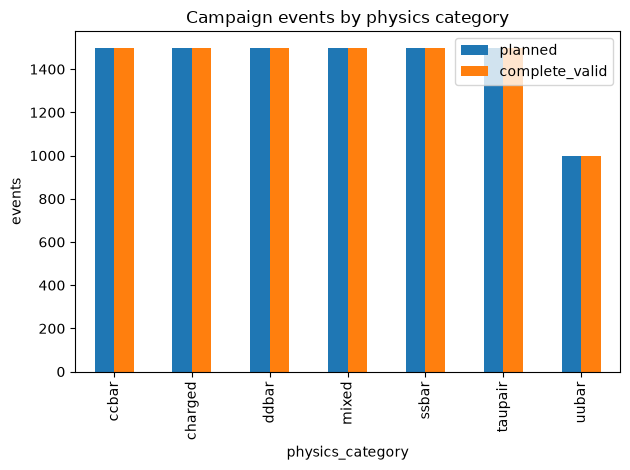

In [4]:
task_status = pd.DataFrame(status["task_status"])
display(task_status)
planned = frame.groupby("physics_category").planned_events.sum()
completed_ids = set(task_status.loc[
    task_status.classification.eq("COMPLETE_VALID"), "task_id"
])
completed = frame[frame.task_id.isin(completed_ids)].groupby(
    "physics_category"
).planned_events.sum().reindex(planned.index, fill_value=0)
pd.DataFrame({"planned": planned, "complete_valid": completed}).plot.bar(
    title="Campaign events by physics category"
)
plt.ylabel("events")
plt.tight_layout()
plt.savefig(REPORT_ROOT / "campaign_category_completion.png", dpi=140)
plt.show()

,task_id,physics_category,events,elapsed_seconds,events_per_second,peak_resident_memory_kib,output_bytes
0,0,ccbar,500,26.836074,18.631637,551356,6091561
1,1,charged,500,30.092536,16.615416,550204,7953569
2,2,ddbar,500,16.710245,29.921764,506976,4550640
3,3,mixed,500,31.104345,16.074925,589424,8044827
4,4,ssbar,500,25.619895,19.516083,533504,4770731
5,5,taupair,500,22.219715,22.502539,460044,2599373
6,6,uubar,500,30.081396,16.621569,456132,4370750
7,7,ccbar,500,36.361502,13.750807,608688,6040150
8,8,charged,500,54.801309,9.123870,578676,7986645
9,9,ddbar,500,42.707700,11.707491,477068,4391357


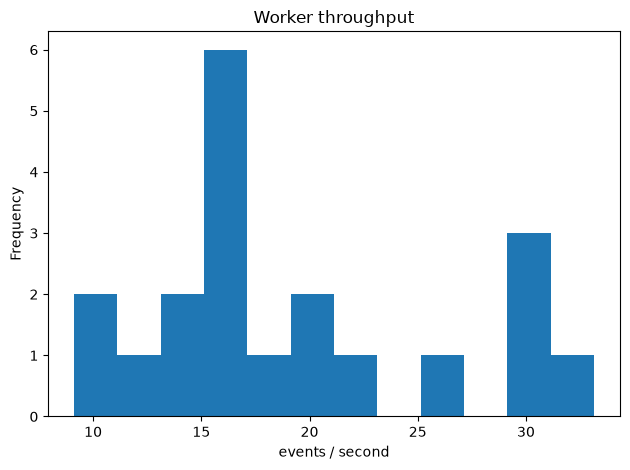

In [5]:
result_rows = []
for row in records:
    result_path = Path(row["output_file"]).with_suffix(".parquet.result.json")
    if result_path.is_file():
        result_rows.append(json.loads(result_path.read_text()))
results = pd.DataFrame(result_rows)
if not results.empty:
    display(results[[
        "task_id", "physics_category", "events", "elapsed_seconds",
        "events_per_second", "peak_resident_memory_kib", "output_bytes",
    ]].sort_values("task_id"))
    results.events_per_second.plot.hist(bins=12, title="Worker throughput")
    plt.xlabel("events / second")
    plt.tight_layout()
    plt.savefig(REPORT_ROOT / "worker_throughput.png", dpi=140)
    plt.show()

In [6]:
log_root = CAMPAIGN_ROOT / "logs" / "condor"
err_files = sorted(log_root.glob("*.err"))
out_files = sorted(log_root.glob("*.out"))
nonempty_errors = [path for path in err_files if path.stat().st_size]
log_summary = {
    "log_root": str(log_root),
    "stdout_files": len(out_files),
    "stderr_files": len(err_files),
    "nonempty_stderr_files": len(nonempty_errors),
    "event_log_files": len(list(log_root.glob("*.log"))),
}
print(json.dumps(log_summary, indent=2))
for path in nonempty_errors[:10]:
    print(f"--- {path.name} (last 20 lines) ---")
    print("\n".join(path.read_text(errors="replace").splitlines()[-20:]))

{
  "log_root": "/data/dust/user/boyangyu/hypertagging/production_10k_middle_20260804/logs/condor",
  "stdout_files": 71,
  "stderr_files": 71,
  "nonempty_stderr_files": 71,
  "event_log_files": 4
}
--- mdst-10k-4716852.0.err (last 20 lines) ---
/cvmfs/belle.cern.ch/tools/b2presetup.sh: line 1: VO_BELLE2_SW_DIR: unbound variable
--- mdst-10k-4716852.1.err (last 20 lines) ---
/cvmfs/belle.cern.ch/tools/b2presetup.sh: line 1: VO_BELLE2_SW_DIR: unbound variable
--- mdst-10k-4716852.10.err (last 20 lines) ---
/cvmfs/belle.cern.ch/tools/b2presetup.sh: line 1: VO_BELLE2_SW_DIR: unbound variable
--- mdst-10k-4716852.11.err (last 20 lines) ---
/cvmfs/belle.cern.ch/tools/b2presetup.sh: line 1: VO_BELLE2_SW_DIR: unbound variable
--- mdst-10k-4716852.12.err (last 20 lines) ---
/cvmfs/belle.cern.ch/tools/b2presetup.sh: line 1: VO_BELLE2_SW_DIR: unbound variable
--- mdst-10k-4716852.13.err (last 20 lines) ---
/cvmfs/belle.cern.ch/tools/b2presetup.sh: line 1: VO_BELLE2_SW_DIR: unbound variable
--- 

## Takeaways

In [7]:
global_validation = None
if status["missing_or_invalid"] == 0:
    global_validation = production.validate_production_manifest(MANIFEST)
report = {
    "artifact": "real_10k_campaign_status",
    "fixture_or_real": "real",
    "manifest": str(MANIFEST),
    "summary": tldr,
    "input_selection": sample,
    "status": status,
    "condor_logs": log_summary,
    "worker_result_count": len(result_rows),
    "global_validation": global_validation,
    "pass_fail_status": (
        "PASS" if global_validation and global_validation["validated_events"] == 10_000
        else "INCOMPLETE"
    ),
}
report_path = REPORT_ROOT / "campaign_status_report.json"
report_path.write_text(json.dumps(report, indent=2, sort_keys=True))
print(json.dumps({
    "report": str(report_path),
    "pass_fail_status": report["pass_fail_status"],
    "validated_events": None if global_validation is None else global_validation["validated_events"],
    "unique_event_uids": None if global_validation is None else global_validation["unique_event_uids"],
}, indent=2))
if require_complete:
    assert report["pass_fail_status"] == "PASS"

{
  "report": "/data/dust/user/boyangyu/hypertagging/production_10k_middle_20260804/inspection/campaign_status_report.json",
  "pass_fail_status": "PASS",
  "validated_events": 10000,
  "unique_event_uids": 10000
}
